In [127]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [128]:
np.random.seed(42)
n = 200
x = np.linspace(-5, 5, n)
noise = np.random.normal(0, 2, n)
y = x**2 + noise

y2 = y**2
xy = x * y

X = np.column_stack([x, y2, xy])

## Non-linear Relationship & Polynomial Features

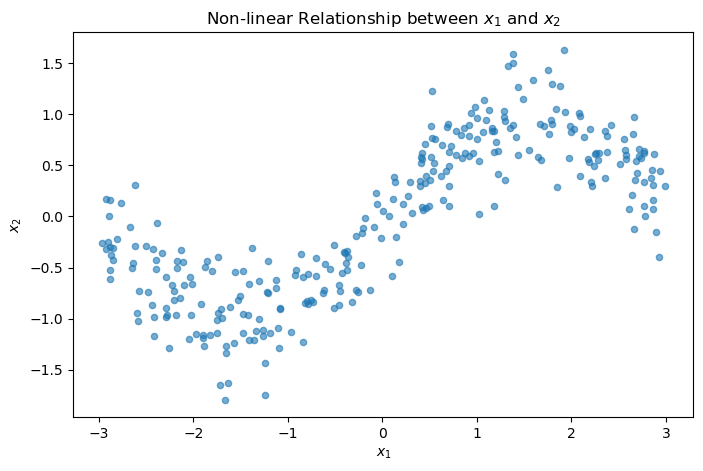

In [129]:
np.random.seed(0)
n = 300
x1 = np.random.uniform(-3, 3, n)
x2 = np.sin(x1) + np.random.normal(0, 0.3, n)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x1, x2, alpha=0.6, s=20)
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('Non-linear Relationship between $x_1$ and $x_2$')
plt.show()

In [130]:
X_input = np.column_stack([x1, x2])
DEGREE = 3

poly = PolynomialFeatures(degree=DEGREE, include_bias=False)
X_poly = poly.fit_transform(X_input)

print('Original features:', poly.n_features_in_)
print('Polynomial features:', X_poly.shape[1])
print('Feature names:', poly.get_feature_names_out())

Original features: 2
Polynomial features: 9
Feature names: ['x0' 'x1' 'x0^2' 'x0 x1' 'x1^2' 'x0^3' 'x0^2 x1' 'x0 x1^2' 'x1^3']


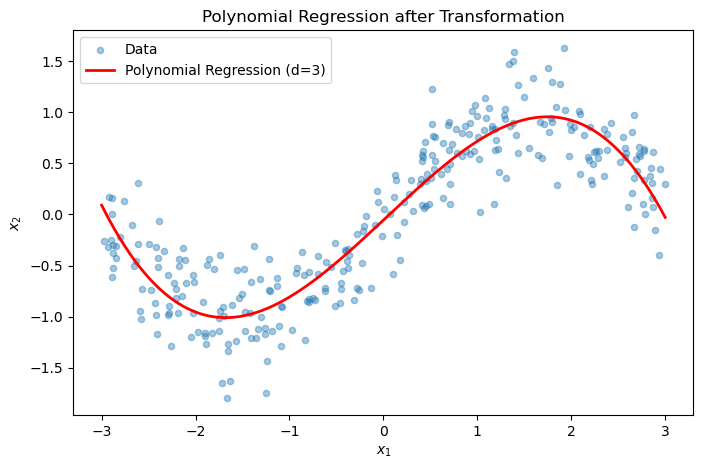

In [131]:
poly_reg = PolynomialFeatures(degree=DEGREE, include_bias=False)
x1_poly = poly_reg.fit_transform(x1.reshape(-1, 1))

reg = LinearRegression().fit(x1_poly, x2)

x1_sorted = np.linspace(-3, 3, 300)
x1_sorted_poly = poly_reg.transform(x1_sorted.reshape(-1, 1))
x2_pred = reg.predict(x1_sorted_poly)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x1, x2, alpha=0.4, s=20, label='Data')
ax.plot(x1_sorted, x2_pred, color='red', linewidth=2, label=f'Polynomial Regression (d={DEGREE})')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('Polynomial Regression after Transformation')
ax.legend()
plt.show()

In [132]:
reg_high = LinearRegression().fit(X_poly, x2)

feat_a, feat_b = 0, 1

a_range = np.linspace(X_poly[:, feat_a].min(), X_poly[:, feat_a].max(), 30)
b_range = np.linspace(X_poly[:, feat_b].min(), X_poly[:, feat_b].max(), 30)
a_grid, b_grid = np.meshgrid(a_range, b_range)

grid_points = np.zeros((30 * 30, X_poly.shape[1]))
grid_points[:, feat_a] = a_grid.ravel()
grid_points[:, feat_b] = b_grid.ravel()

mean_vals = X_poly.mean(axis=0)
for i in range(X_poly.shape[1]):
    if i not in [feat_a, feat_b]:
        grid_points[:, i] = mean_vals[i]

z_pred = reg_high.predict(grid_points).reshape(30, 30)

fig = go.Figure()

fig.add_trace(go.Scatter3d(
    x=X_poly[:, feat_a], y=X_poly[:, feat_b], z=x2,
    mode='markers',
    marker=dict(size=3, color=x2, colorscale='Viridis', opacity=0.6),
    name='Data points'
))

fig.add_trace(go.Surface(
    x=a_grid, y=b_grid, z=z_pred,
    colorscale='Reds', opacity=0.5,
    name='Regression plane'
))

feature_names = poly.get_feature_names_out()
fig.update_layout(
    scene=dict(
        xaxis_title=feature_names[feat_a],
        yaxis_title=feature_names[feat_b],
        zaxis_title='$x_2$ (target)'
    ),
    height=700, width=900,
    title=f'Regression Plane (degree={DEGREE}) in High-Dimensional Space'
)
fig.show()